#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

#### Useful functions/classes

In [2]:
def normalize(data):
    datamin = data.min()
    datamax = data.max()
    normal = (data - datamin) / (datamax - datamin)
    return normal, datamin, datamax


### Reads block files in input_dir up to a maximum time step (max), flattens blocks to be 1x, and
### stores them in a nested list of format all_data[spatial_location[time_step[flattened_block_index]]]
def process_data(input_dir, min, max, block_dim, component):

    num_blocks = int((256/block_dim) * (96/block_dim) * (96/block_dim))

    # Set up nested list to store data
    all_data = []
    for l in range(num_blocks):
        all_data.append([])
        for t in range(min, max):
            all_data[l].append([])

    for t in range(min, max): # iterate over each time step
        filename = input_dir + str(t) + "-" + str(block_dim) + "-" + str(component) + ".raw"
        with open(filename, "rb") as file:
            for l in range(num_blocks): # iterate over each location
                for i in range(block_dim**3): # iterate through the block
                    all_data[l][t-74].append(struct.unpack('<f', file.read(4))[0])
        if (t-73) % 10 == 0:
            print("Processed data from first",str(t-73),"time steps")

    return all_data


def create_samples(data, n):
    x = []
    y = []
    for l in range(len(data)):
        ldata = data[l]
        for t in range(1, len(ldata) - 1):
            input = []
            for i in range(len(ldata[0])):
                input.append(ldata[0][i])
            for i in range(len(ldata[n-1])):
                input.append(ldata[n-1][i])
            # input.append(t)
            # input.append(l)
            x.append(input)
            y.append(ldata[t])

    x = np.array(x)
    y = np.array(y)
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


class CombustionData(Dataset):
    def __init__(self, X_full, y_full):
        super().__init__()
        self.X_full = X_full
        self.y_full = y_full

    def __len__(self):
        return len(self.X_full)

    def __getitem__(self, idx):
        input = self.X_full[idx]
        output = self.y_full[idx]
        return input, output

#### Hyperparameters

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
lr = 3e-4
batch_size = 256
epochs = 3000

Running on cuda


In [4]:
data = process_data("volumes8-6/", 74, 83, 8, 6)
x, y = create_samples(data, 8)
print(x.shape)
print(y.shape)

# Scale the data to be between -1 and 1
xmin = x.min()
xmax = x.max()
ymin = y.min()
ymax = y.max()
xnormal = (x - xmin) / (xmax - xmin)
ynormal = (y - ymin) / (ymax - ymin)
xfinal = torch.empty((xnormal.shape[0], xnormal.shape[1]+2))
print(xfinal.shape)

# Add t and l data to the input samples
sample_idx = 0
for l in range(len(data)):
    ldata = data[l]
    for t in range(1, len(ldata)-1):
        time = torch.tensor([t])
        loc = torch.tensor([l])
        new = torch.cat((xnormal[sample_idx], time, loc))
        xfinal[sample_idx] = new
        sample_idx += 1

# Initialize the dataset, split into train and validate sets, and create loaders
dataset = CombustionData(xfinal, ynormal)
#train_data, val_data = random_split(dataset, [0.9, 0.1])
train_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
#test_loader = DataLoader(dataset=val_data, batch_size=batch_size, shuffle=False)

torch.Size([32256, 1024])
torch.Size([32256, 512])
torch.Size([32256, 1026])


#### Model Initialization

In [5]:
class CompressionModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(CompressionModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.fc2 = nn.Linear(1024, 2048)
        self.fc3 = nn.Linear(2048, 4096)
        self.fc4 = nn.Linear(4096, 9182)
        # self.fc5 = nn.Linear(9182, 18364)
        # self.fc6 = nn.Linear(18364, 9182)
        self.fc7 = nn.Linear(9182, 4096)
        self.fc8 = nn.Linear(4096, 2048)
        self.fc9 = nn.Linear(2048, 1024)
        self.fc10 = nn.Linear(1024, output_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)
        self.sig = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.relu(self.fc4(x))
        x = self.dropout(x)
        # x = self.relu(self.fc5(x))
        # x = self.dropout(x)
        # x = self.relu(self.fc6(x))
        # x = self.dropout(x)
        x = self.relu(self.fc7(x))
        x = self.dropout(x)
        x = self.relu(self.fc8(x))
        x = self.dropout(x)
        x = self.relu(self.fc9(x))
        x = self.dropout(x)
        x = self.fc10(x)
        #x = self.sig(x)
        return x

model = CompressionModel(1026, 512).to(device)

#### Train model

In [6]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

early_stop_count = 0
min_train_loss = float('inf')

train_hist = []

for epoch in range(epochs):
    # Training
    #model.train()
    train_losses = []
    for batch in train_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        train_losses.append(loss.item())
        loss.backward()
        optimizer.step()
    train_loss = np.mean(train_losses)
    train_hist.append(train_loss)

    # Validation
    # model.eval()
    # val_losses = []
    # with torch.no_grad():
    #     for batch in test_loader:
    #         x_batch, y_batch = batch
    #         x_batch, y_batch = x_batch.to(device), y_batch.to(device)

    #         outputs = model(x_batch)
    #         loss = criterion(outputs, y_batch)
    #         val_losses.append(loss.item())
    # val_loss = np.mean(val_losses)
    # val_hist.append(val_loss)

    # if train_loss < min_train_loss:
    #     min_train_loss = train_loss
    #     early_stop_count = 0
    # else:
    #     early_stop_count += 1
 
    # if early_stop_count >= 20:
    #     print("Early stopping!")
    #     break
    
    #if (epoch+1) % 100 == 0:
    print(f"Epoch {epoch + 1}/{epochs}: Training Loss = {train_loss:.8f}")

Epoch 1/3000: Training Loss = 0.05377140
Epoch 2/3000: Training Loss = 0.00532108
Epoch 3/3000: Training Loss = 0.00490643
Epoch 4/3000: Training Loss = 0.00435393
Epoch 5/3000: Training Loss = 0.00413290


KeyboardInterrupt: 

#### Plot loss

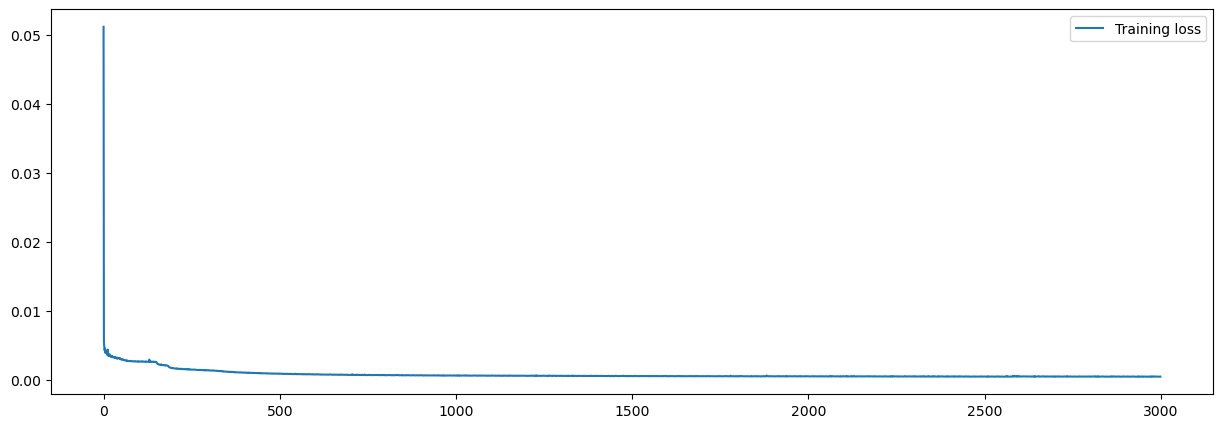

In [16]:
plt.figure(figsize=(15,5))
plt.plot(range(3000), train_hist, label='Training loss')
#plt.plot(range(31), val_hist, label='Validation loss')
plt.legend()

#### Calc size of model

In [17]:
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()
size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 373.037MB


#### Save model

In [9]:
torch.save(model.state_dict(), "testModels/model1.pt")

#### Generate timestep using learned model

In [19]:
def generate_output(obs, model, step, block_dim, n):

    # Translate step from filename to actual position
    step = step - 74

    num_blocks = int((256/block_dim) * (96/block_dim) * (96/block_dim))
    
    preds = [] # Ultimately 4608x1x512
    
    # Generate a prediction for each location using the model
    for l in range(num_blocks):
        input = []
        for i in range(len(obs[l][0])):
            normal = (obs[l][0][i] - xmin) / (xmax - xmin)
            input.append(normal)
        for i in range(len(obs[l][n-1])):
            normal = (obs[l][n-1][i] - xmin) / (xmax - xmin)
            input.append(normal)
        input.append(step)
        input.append(l)
        input = torch.tensor(input).to(device)
        pred = model(input)
        pred = pred.cpu().detach().numpy()
        preds.append(pred)

    # Unpack preds and reshape to be one volume
    preds = np.array(preds)
    preds = torch.tensor(preds, dtype=torch.float32).squeeze()
    preds = preds * (ymax - ymin) + ymin
    print(preds.shape)

    xsteps = int(256/block_dim)
    ysteps = int(96/block_dim)
    zsteps = int(96/block_dim)

    prediction = np.empty((256, 96, 96))
    block_num = 0

    for k in range(zsteps):
        for j in range(ysteps):
            for i in range(xsteps):
                x_lo = int(i * block_dim)
                y_lo = int(j * block_dim)
                z_lo = int(k * block_dim)
                block_idx = 0
                for z in range(block_dim):
                    for y in range(block_dim):
                        for x in range(block_dim):
                            prediction[x_lo + x][y_lo + y][z_lo + z] = preds[block_num][block_idx]
                            block_idx += 1
                block_num += 1

    return prediction


# Retrieve and assemble the known output
def get_output(obs, step, block_dim):

    # Translate step from filename to actual position
    step = step - 74

    num_blocks = int((256/block_dim) * (96/block_dim) * (96/block_dim))

    reals = []

    for l in range(num_blocks):
        lobs = obs[l]
        real = lobs[step]
        real = np.array(real)
        reals.append(real)

    reals = np.array(reals)
    reals = torch.tensor(reals, dtype=torch.float32)
    print(reals.shape)

    xsteps = int(256/block_dim)
    ysteps = int(96/block_dim)
    zsteps = int(96/block_dim)

    actual = np.empty((256, 96, 96))
    block_num = 0

    for k in range(zsteps):
        for j in range(ysteps):
            for i in range(xsteps):
                x_lo = int(i * block_dim)
                y_lo = int(j * block_dim)
                z_lo = int(k * block_dim)
                block_idx = 0
                for z in range(block_dim):
                    for y in range(block_dim):
                        for x in range(block_dim):
                            actual[x_lo + x][y_lo + y][z_lo + z] = reals[block_num][block_idx]
                            block_idx += 1
                block_num += 1

    return actual

In [20]:
prediction = generate_output(data, model, 80, 8, 8)
actual = get_output(data, 80, 8)

torch.Size([4608, 512])
torch.Size([4608, 512])


In [21]:
def calc_mse(actual, predicted):

    xdim = actual.shape[0]
    ydim = actual.shape[1]
    zdim = actual.shape[2]

    sum = 0

    for k in range(zdim):
        for j in range(ydim):
            for i in range(xdim):
                sq = (actual[i][j][k] - predicted[i][j][k])**2
                sum += sq

    mse = sum / (xdim * ydim * zdim)

    return mse

mse = calc_mse(actual, prediction)
rmse = mse**0.5
print(rmse)

45.116491621505276


In [14]:
var = torch.std(y)
print(var)
print(ymin)
print(ymax)

tensor(196.2583)
tensor(338.6722)
tensor(2385.5376)


#### Write prediction and actual to be visualized

In [20]:
def write_to_visualize(volume, path, out_file):
    filename = path + out_file
    with open(filename, "wb") as file:
        volume.tofile(file)

delta = actual - prediction

write_to_visualize(prediction, "toVisualize/", "compression-prediction.raw")
write_to_visualize(actual, "toVisualize/", "compression-actual.raw")
write_to_visualize(delta, "toVisualize/", "compression-delta.raw")